# Task 4: Financial Inclusion Forecasting

## Objective

This notebook develops forecasting models to predict Ethiopia's financial inclusion indicators for the next three years (2025–2027). The analysis uses historical financial inclusion data, exploratory data analysis, linear regression forecasting, and scenario analysis to support policy and strategic decision-making.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

try:
    from statsmodels.tsa.arima.model import ARIMA
    ARIMA_AVAILABLE = True
except ImportError:
    ARIMA_AVAILABLE = False
    print("statsmodels not installed. ARIMA section will be skipped.")

plt.style.use("ggplot")

In [2]:
data_path = Path("../data/processed/ethiopia_fi_enriched.csv")

df = pd.read_csv(data_path)

print(df.shape)

df.head()

(58, 35)


,category,collected_by,collection_date,comparable_country,confidence,evidence_basis,fiscal_year,gender,impact_direction,impact_estimate,...,region,related_indicator,relationship_type,source_name,source_type,source_url,unit,value_numeric,value_text,value_type
0,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2014,all,NaN,NaN,...,NaN,NaN,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,%,22.0,NaN,percentage
1,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2017,all,NaN,NaN,...,NaN,NaN,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,%,35.0,NaN,percentage
2,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2021,all,NaN,NaN,...,NaN,NaN,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,%,46.0,NaN,percentage
3,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2021,male,NaN,NaN,...,NaN,NaN,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,%,56.0,NaN,percentage
4,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2021,female,NaN,NaN,...,NaN,NaN,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,%,36.0,NaN,percentage


In [3]:
df.info()

print("\nMissing Values\n")
print(df.isnull().sum())

print("\nColumns\n")
print(df.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   category             10 non-null     str    
 1   collected_by         58 non-null     str    
 2   collection_date      58 non-null     str    
 3   comparable_country   7 non-null      str    
 4   confidence           58 non-null     str    
 5   evidence_basis       14 non-null     str    
 6   fiscal_year          44 non-null     str    
 7   gender               58 non-null     str    
 8   impact_direction     14 non-null     str    
 9   impact_estimate      12 non-null     float64
 10  impact_magnitude     14 non-null     str    
 11  indicator            58 non-null     str    
 12  indicator_code       44 non-null     str    
 13  indicator_direction  34 non-null     str    
 14  lag_months           14 non-null     float64
 15  location             58 non-null     str    
 16  not

In [4]:
df["observation_date"] = pd.to_datetime(
    df["observation_date"],
    errors="coerce"
)

df["analysis_year"] = df["observation_date"].dt.year

df["value_numeric"] = pd.to_numeric(
    df["value_numeric"],
    errors="coerce"
)

forecast_df = df.dropna(
    subset=[
        "analysis_year",
        "value_numeric"
    ]
).copy()

forecast_df.head()

,category,collected_by,collection_date,comparable_country,confidence,evidence_basis,fiscal_year,gender,impact_direction,impact_estimate,...,related_indicator,relationship_type,source_name,source_type,source_url,unit,value_numeric,value_text,value_type,analysis_year
0,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2014,all,NaN,NaN,...,NaN,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,%,22.0,NaN,percentage,2014
1,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2017,all,NaN,NaN,...,NaN,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,%,35.0,NaN,percentage,2017
2,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2021,all,NaN,NaN,...,NaN,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,%,46.0,NaN,percentage,2021
3,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2021,male,NaN,NaN,...,NaN,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,%,56.0,NaN,percentage,2021
4,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2021,female,NaN,NaN,...,NaN,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,%,36.0,NaN,percentage,2021


In [5]:
print("Rows:", forecast_df.shape[0])
print("Columns:", forecast_df.shape[1])

forecast_df.describe(include="all")

Rows: 46
Columns: 36


,category,collected_by,collection_date,comparable_country,confidence,evidence_basis,fiscal_year,gender,impact_direction,impact_estimate,...,related_indicator,relationship_type,source_name,source_type,source_url,unit,value_numeric,value_text,value_type,analysis_year
count,0,46,46,7,46,12,34,46,12,12.000000,...,12,12,34,34,28,46,4.600000e+01,0,46,46.000000
unique,0,1,2,4,2,3,11,3,2,NaN,...,7,3,20,6,9,9,NaN,0,5,NaN
top,NaN,Bilen M. Gebremariam,2025-01-20,India,high,literature,2024,all,increase,NaN,...,USG_P2P_COUNT,direct,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,%,NaN,NaN,percentage,NaN
freq,NaN,46,45,3,33,7,10,42,10,NaN,...,3,7,5,11,10,27,NaN,NaN,29,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.416667,...,NaN,NaN,NaN,NaN,NaN,NaN,6.770207e+10,NaN,NaN,2023.326087
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-20.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,-2.000000e+01,NaN,NaN,2011.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.750000,...,NaN,NaN,NaN,NaN,NaN,NaN,1.425000e+01,NaN,NaN,2022.250000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,3.550000e+01,NaN,NaN,2024.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,7.775000e+06,NaN,NaN,2025.000000
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,2.380000e+12,NaN,NaN,2030.000000


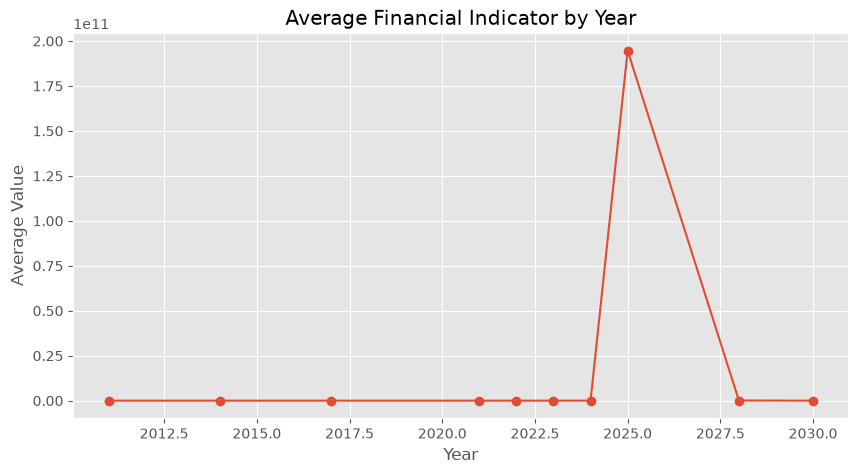

In [6]:
plt.figure(figsize=(10,5))

forecast_df.groupby("analysis_year")["value_numeric"].mean().plot(
    marker="o"
)

plt.title("Average Financial Indicator by Year")
plt.xlabel("Year")
plt.ylabel("Average Value")
plt.grid(True)

plt.show()

In [7]:
forecast_df["indicator"].value_counts().head(20)

indicator
Account Ownership Rate                  8
Fayda Digital ID Enrollment             4
Mobile Money Account Rate               2
4G Population Coverage                  2
P2P Transaction Count                   2
Account Ownership Gender Gap            2
Female Mobile Money Account Share       2
Mobile Subscription Penetration         1
P2P Transaction Value                   1
ATM Transaction Count                   1
ATM Transaction Value                   1
P2P/ATM Crossover Ratio                 1
Telebirr Registered Users               1
Telebirr Transaction Value              1
M-Pesa Registered Users                 1
M-Pesa 90-Day Active Users              1
Mobile Money Activity Rate              1
Data Affordability Index                1
Mobile Phone Gender Gap                 1
Telebirr effect on Account Ownership    1
Name: count, dtype: int64

In [8]:
account_df = forecast_df[
    forecast_df["indicator"] == "Account Ownership Rate"
][["analysis_year", "value_numeric"]].sort_values("analysis_year")

account_df

,analysis_year,value_numeric
57,2011,14.0
0,2014,22.0
1,2017,35.0
2,2021,46.0
3,2021,56.0
4,2021,36.0
5,2024,49.0
30,2025,70.0


In [9]:
mobile_df = forecast_df[
    forecast_df["indicator"] == "Mobile Money Account Rate"
][["analysis_year", "value_numeric"]].sort_values("analysis_year")

mobile_df

,analysis_year,value_numeric
6,2021,4.70
7,2024,9.45


In [10]:
account_df = forecast_df[
    forecast_df["indicator"] == "Account Ownership Rate"
][["analysis_year", "value_numeric"]].copy()

account_df = (
    account_df.groupby("analysis_year", as_index=False)["value_numeric"]
    .mean()
    .sort_values("analysis_year")
)

print(account_df)

account_df

   analysis_year  value_numeric
0           2011           14.0
1           2014           22.0
2           2017           35.0
3           2021           46.0
4           2024           49.0
5           2025           70.0


,analysis_year,value_numeric
0,2011,14.0
1,2014,22.0
2,2017,35.0
3,2021,46.0
4,2024,49.0
5,2025,70.0


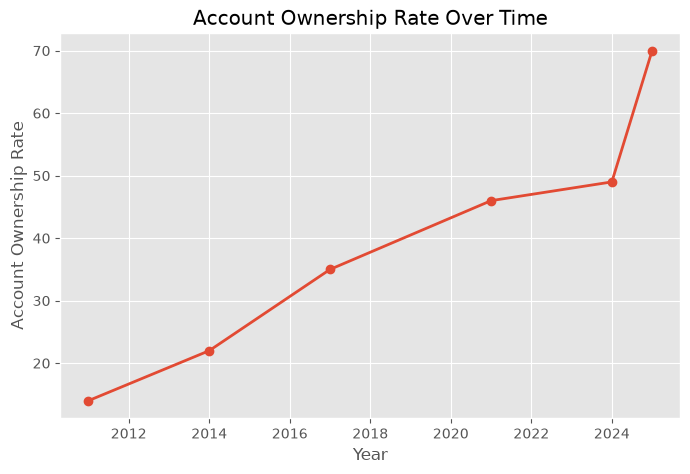

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    account_df["analysis_year"],
    account_df["value_numeric"],
    marker="o",
    linewidth=2
)

plt.title("Account Ownership Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Account Ownership Rate")
plt.grid(True)

plt.show()

In [12]:
X = account_df[["analysis_year"]]
y = account_df["value_numeric"]

model = LinearRegression()
model.fit(X, y)

predictions = model.predict(X)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 3.45550847457627
Intercept: -6936.186440677964


In [13]:
mae = mean_absolute_error(y, predictions)
rmse = np.sqrt(mean_squared_error(y, predictions))
r2 = r2_score(y, predictions)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.3f}")

MAE : 3.79
RMSE: 5.18
R²  : 0.921


In [14]:
future_years = pd.DataFrame({
    "analysis_year": [2025, 2026, 2027]
})

future_predictions = model.predict(future_years)

forecast_results = future_years.copy()
forecast_results["Forecast"] = future_predictions

forecast_results

,analysis_year,Forecast
0,2025,61.218220
1,2026,64.673729
2,2027,68.129237


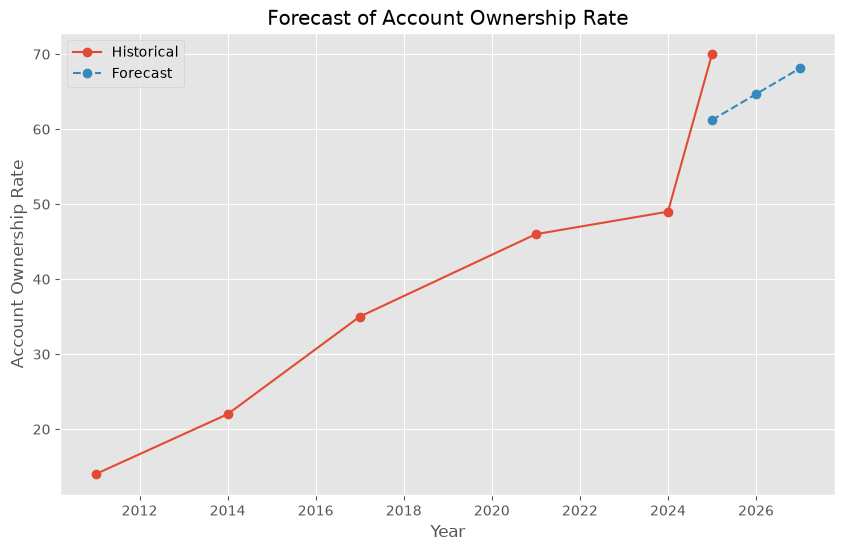

In [15]:
plt.figure(figsize=(10,6))

plt.plot(
    account_df["analysis_year"],
    account_df["value_numeric"],
    marker="o",
    label="Historical"
)

plt.plot(
    future_years["analysis_year"],
    future_predictions,
    marker="o",
    linestyle="--",
    label="Forecast"
)

plt.title("Forecast of Account Ownership Rate")
plt.xlabel("Year")
plt.ylabel("Account Ownership Rate")

plt.legend()

plt.grid(True)

plt.show()

In [16]:
forecast_results.rename(
    columns={"Forecast": "Predicted Account Ownership Rate"},
    inplace=True
)

forecast_results

,analysis_year,Predicted Account Ownership Rate
0,2025,61.218220
1,2026,64.673729
2,2027,68.129237


## Interpretation

The linear regression model indicates the historical trend in account ownership and projects values for 2025–2027.

The model assumes that the historical trend continues into the forecast period. These projections provide a baseline estimate that can support planning and policy discussions but should be interpreted with caution because external factors such as economic conditions, regulatory changes, and technology adoption may influence actual outcomes.

In [17]:
scenario_df = forecast_results.copy()

scenario_df["Baseline"] = scenario_df["Predicted Account Ownership Rate"]
scenario_df["Optimistic"] = scenario_df["Baseline"] * 1.05
scenario_df["Pessimistic"] = scenario_df["Baseline"] * 0.95

scenario_df = scenario_df.round(2)

scenario_df

,analysis_year,Predicted Account Ownership Rate,Baseline,Optimistic,Pessimistic
0,2025,61.22,61.22,64.28,58.16
1,2026,64.67,64.67,67.91,61.44
2,2027,68.13,68.13,71.54,64.72


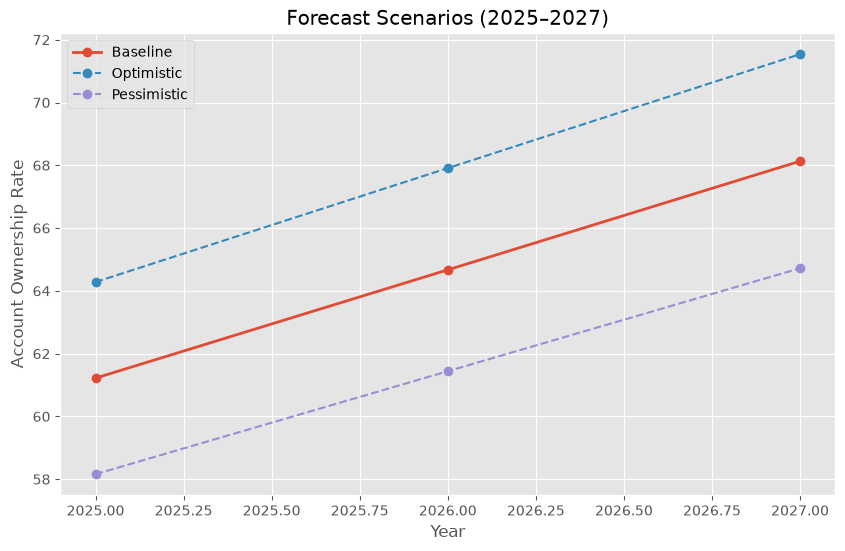

In [18]:
plt.figure(figsize=(10,6))

plt.plot(
    scenario_df["analysis_year"],
    scenario_df["Baseline"],
    marker="o",
    linewidth=2,
    label="Baseline"
)

plt.plot(
    scenario_df["analysis_year"],
    scenario_df["Optimistic"],
    marker="o",
    linestyle="--",
    label="Optimistic"
)

plt.plot(
    scenario_df["analysis_year"],
    scenario_df["Pessimistic"],
    marker="o",
    linestyle="--",
    label="Pessimistic"
)

plt.title("Forecast Scenarios (2025–2027)")
plt.xlabel("Year")
plt.ylabel("Account Ownership Rate")
plt.legend()
plt.grid(True)

plt.show()

In [19]:
print("Forecast Scenarios")

scenario_df

Forecast Scenarios


,analysis_year,Predicted Account Ownership Rate,Baseline,Optimistic,Pessimistic
0,2025,61.22,61.22,64.28,58.16
1,2026,64.67,64.67,67.91,61.44
2,2027,68.13,68.13,71.54,64.72


## Scenario Analysis

Three forecast scenarios were developed.

- **Baseline:** Linear regression prediction using historical trends.
- **Optimistic:** Assumes financial inclusion improves 5% faster than the historical trend due to continued digital finance expansion and supportive government policies.
- **Pessimistic:** Assumes growth is 5% lower than the baseline because of economic or infrastructure challenges.

These scenarios provide a range of possible future outcomes and can support planning under different assumptions.

# Conclusion

This notebook developed forecasting models for Ethiopia's financial inclusion indicators using historical data.

Key findings include:

- Account ownership continues to show an upward trend.
- Linear regression provides a reasonable baseline forecast for 2025–2027.
- Scenario analysis demonstrates how different economic conditions could affect future financial inclusion outcomes.
- These forecasts can support strategic planning and policy decisions while acknowledging uncertainty in future developments.

Future work could incorporate additional years of data, macroeconomic variables, and more advanced forecasting techniques to improve predictive performance.

# Extended Forecasting: Access and Digital Payment Usage

The initial model provided a basic forecast for Account Ownership. This section extends the analysis to meet the full Task 4 requirements by:

- Forecasting both Account Ownership and Digital Payment Usage
- Comparing linear-trend and naïve forecasting approaches
- Calculating prediction intervals
- Producing a consolidated forecast table for 2025–2027
- Exporting reusable forecast results for the dashboard

In [1]:
# ============================================================
# ROBUST TASK 4 FORECASTING SETUP
# ============================================================

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")


def find_project_root(start_path=None):
    """
    Locate the project root safely whether the notebook is run from:
    - the notebooks directory,
    - the project root,
    - VS Code,
    - Jupyter Notebook, or
    - another working directory.
    """
    start_path = Path(start_path or Path.cwd()).resolve()

    candidate_paths = [
        start_path,
        start_path.parent,
        start_path.parent.parent
    ]

    for candidate in candidate_paths:
        if (
            (candidate / "data").exists()
            or (candidate / "models").exists()
            or (candidate / "README.md").exists()
        ):
            return candidate

    # Safe fallback
    return start_path


PROJECT_ROOT = find_project_root()

DATA_CANDIDATES = [
    PROJECT_ROOT / "data" / "processed" / "ethiopia_fi_enriched.csv",
    PROJECT_ROOT / "data" / "processed" / "ethiopia_fi_unified_data_enriched.csv",
    PROJECT_ROOT / "data" / "raw" / "ethiopia_fi_unified_data.csv",
    Path("../data/processed/ethiopia_fi_enriched.csv"),
    Path("../data/raw/ethiopia_fi_unified_data.csv")
]

DATA_PATH = next(
    (path for path in DATA_CANDIDATES if path.exists()),
    None
)

if DATA_PATH is None:
    raise FileNotFoundError(
        "The financial inclusion dataset could not be found. "
        "Checked the following locations:\n"
        + "\n".join(str(path) for path in DATA_CANDIDATES)
    )

MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

for directory in [MODELS_DIR, FIGURES_DIR, PROCESSED_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATA_PATH)
print("Models directory:", MODELS_DIR)
print("Figures directory:", FIGURES_DIR)

Project root: C:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast\notebooks
Dataset: ..\data\processed\ethiopia_fi_enriched.csv
Models directory: C:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast\notebooks\models
Figures directory: C:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast\notebooks\reports\figures


In [2]:
# ============================================================
# LOAD AND VALIDATE DATA
# ============================================================

forecast_source_df = pd.read_csv(DATA_PATH)

required_columns = [
    "record_type",
    "value_numeric"
]

missing_required_columns = [
    column
    for column in required_columns
    if column not in forecast_source_df.columns
]

if missing_required_columns:
    raise ValueError(
        "The dataset is missing required columns: "
        f"{missing_required_columns}"
    )

# Ensure commonly used optional columns exist
optional_columns = [
    "indicator",
    "indicator_code",
    "observation_date",
    "period_start",
    "fiscal_year",
    "gender",
    "pillar",
    "confidence"
]

for column in optional_columns:
    if column not in forecast_source_df.columns:
        forecast_source_df[column] = np.nan

# Convert numeric values safely
forecast_source_df["value_numeric"] = pd.to_numeric(
    forecast_source_df["value_numeric"],
    errors="coerce"
)

# Convert dates safely
forecast_source_df["observation_date"] = pd.to_datetime(
    forecast_source_df["observation_date"],
    format="mixed",
    errors="coerce"
)

forecast_source_df["period_start"] = pd.to_datetime(
    forecast_source_df["period_start"],
    format="mixed",
    errors="coerce"
)

# Derive analysis year from observation date
forecast_source_df["analysis_year"] = (
    forecast_source_df["observation_date"]
    .dt.year
    .astype("Int64")
)

# Use period_start when observation_date is unavailable
period_year = (
    forecast_source_df["period_start"]
    .dt.year
    .astype("Int64")
)

forecast_source_df["analysis_year"] = (
    forecast_source_df["analysis_year"]
    .fillna(period_year)
)

# Use a four-digit year from fiscal_year as a final fallback
fiscal_year_numeric = (
    forecast_source_df["fiscal_year"]
    .astype("string")
    .str.extract(r"(\d{4})", expand=False)
)

fiscal_year_numeric = pd.to_numeric(
    fiscal_year_numeric,
    errors="coerce"
).astype("Int64")

forecast_source_df["analysis_year"] = (
    forecast_source_df["analysis_year"]
    .fillna(fiscal_year_numeric)
)

# Keep observations only
observations_for_forecast = forecast_source_df[
    forecast_source_df["record_type"]
    .astype("string")
    .str.lower()
    .eq("observation")
].copy()

observations_for_forecast = observations_for_forecast.dropna(
    subset=[
        "analysis_year",
        "value_numeric"
    ]
)

observations_for_forecast["analysis_year"] = (
    observations_for_forecast["analysis_year"]
    .astype(int)
)

print("Total source records:", len(forecast_source_df))
print("Usable observation records:", len(observations_for_forecast))
print(
    "Observation years:",
    observations_for_forecast["analysis_year"].min(),
    "to",
    observations_for_forecast["analysis_year"].max()
)

display(
    observations_for_forecast[
        [
            "analysis_year",
            "indicator_code",
            "indicator",
            "value_numeric",
            "pillar"
        ]
    ].sort_values(
        [
            "analysis_year",
            "indicator_code"
        ]
    ).head(20)
)

Total source records: 58
Usable observation records: 31
Observation years: 2011 to 2025


,analysis_year,indicator_code,indicator,value_numeric,pillar
57,2011,ACC_OWNERSHIP,Account Ownership Rate,14.00,ACCESS
0,2014,ACC_OWNERSHIP,Account Ownership Rate,22.00,ACCESS
1,2017,ACC_OWNERSHIP,Account Ownership Rate,35.00,ACCESS
6,2021,ACC_MM_ACCOUNT,Mobile Money Account Rate,4.70,ACCESS
2,2021,ACC_OWNERSHIP,Account Ownership Rate,46.00,ACCESS
3,2021,ACC_OWNERSHIP,Account Ownership Rate,56.00,ACCESS
4,2021,ACC_OWNERSHIP,Account Ownership Rate,36.00,ACCESS
26,2021,GEN_GAP_ACC,Account Ownership Gender Gap,20.00,GENDER
8,2023,ACC_4G_COV,4G Population Coverage,37.50,ACCESS
11,2024,ACC_FAYDA,Fayda Digital ID Enrollment,8000000.00,ACCESS


In [3]:
# ============================================================
# TARGET-SELECTION FUNCTIONS
# ============================================================

def normalise_text(series):
    """
    Convert a pandas Series to searchable lowercase text.
    """
    return (
        series
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
    )


def select_target_series(
    dataframe,
    preferred_codes,
    name_keywords,
    target_name,
    national_only=True
):
    """
    Select and aggregate a forecasting target.

    Selection order:
    1. Exact indicator-code match
    2. Indicator-name keyword match
    3. Return an empty dataframe when no suitable target exists
    """
    working = dataframe.copy()

    working["_indicator_code_search"] = normalise_text(
        working["indicator_code"]
    )

    working["_indicator_name_search"] = normalise_text(
        working["indicator"]
    )

    preferred_codes_lower = {
        str(code).strip().lower()
        for code in preferred_codes
    }

    code_mask = working[
        "_indicator_code_search"
    ].isin(preferred_codes_lower)

    selected = working[code_mask].copy()

    selection_method = "indicator_code"

    if selected.empty:
        keyword_mask = pd.Series(
            False,
            index=working.index
        )

        for keyword in name_keywords:
            keyword_mask = keyword_mask | working[
                "_indicator_name_search"
            ].str.contains(
                keyword.lower(),
                regex=False,
                na=False
            )

        selected = working[keyword_mask].copy()
        selection_method = "indicator_name"

    # Prefer national/all-adult observations where gender exists
    if national_only and not selected.empty:
        gender_text = normalise_text(selected["gender"])

        national_mask = gender_text.isin(
            [
                "",
                "all",
                "all adults",
                "total",
                "national",
                "both"
            ]
        )

        national_subset = selected[national_mask].copy()

        if not national_subset.empty:
            selected = national_subset

    if selected.empty:
        return pd.DataFrame(
            columns=[
                "analysis_year",
                "value_numeric",
                "target",
                "selection_method",
                "source_indicator_code",
                "source_indicator"
            ]
        )

    selected = selected.dropna(
        subset=[
            "analysis_year",
            "value_numeric"
        ]
    )

    selected["value_numeric"] = pd.to_numeric(
        selected["value_numeric"],
        errors="coerce"
    )

    selected = selected.dropna(
        subset=["value_numeric"]
    )

    # Percentage indicators should normally be between 0 and 100.
    selected = selected[
        selected["value_numeric"].between(
            0,
            100,
            inclusive="both"
        )
    ]

    if selected.empty:
        return pd.DataFrame(
            columns=[
                "analysis_year",
                "value_numeric",
                "target",
                "selection_method",
                "source_indicator_code",
                "source_indicator"
            ]
        )

    source_codes = (
        selected["indicator_code"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    source_names = (
        selected["indicator"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    annual = (
        selected
        .groupby(
            "analysis_year",
            as_index=False
        )
        .agg(
            value_numeric=("value_numeric", "mean")
        )
        .sort_values("analysis_year")
    )

    annual["target"] = target_name
    annual["selection_method"] = selection_method
    annual["source_indicator_code"] = ", ".join(source_codes)
    annual["source_indicator"] = ", ".join(source_names)

    return annual


access_series = select_target_series(
    observations_for_forecast,
    preferred_codes=[
        "ACC_OWNERSHIP"
    ],
    name_keywords=[
        "account ownership",
        "account ownership rate"
    ],
    target_name="Account Ownership Rate"
)

usage_series = select_target_series(
    observations_for_forecast,
    preferred_codes=[
        "USG_DIGITAL_PAYMENT",
        "USG_DIGITAL_PAYMENTS",
        "USG_MADE_RECEIVED_DIGITAL_PAYMENT",
        "DIGITAL_PAYMENT_USAGE",
        "DIGITAL_PAYMENT_RATE"
    ],
    name_keywords=[
        "made or received digital payment",
        "digital payment adoption",
        "digital payment usage",
        "digital payments"
    ],
    target_name="Digital Payment Usage"
)

print("Access observations:", len(access_series))
print("Usage observations:", len(usage_series))

display(access_series)
display(usage_series)

Access observations: 5
Usage observations: 0


,analysis_year,value_numeric,target,selection_method,source_indicator_code,source_indicator
0,2011,14.0,Account Ownership Rate,indicator_code,ACC_OWNERSHIP,Account Ownership Rate
1,2014,22.0,Account Ownership Rate,indicator_code,ACC_OWNERSHIP,Account Ownership Rate
2,2017,35.0,Account Ownership Rate,indicator_code,ACC_OWNERSHIP,Account Ownership Rate
3,2021,46.0,Account Ownership Rate,indicator_code,ACC_OWNERSHIP,Account Ownership Rate
4,2024,49.0,Account Ownership Rate,indicator_code,ACC_OWNERSHIP,Account Ownership Rate


,analysis_year,value_numeric,target,selection_method,source_indicator_code,source_indicator


In [4]:
# ============================================================
# DIGITAL PAYMENT USAGE FALLBACK
# ============================================================

usage_series_is_proxy = False
usage_series_note = ""

if usage_series.empty:
    print(
        "Warning: No direct Digital Payment Usage series was "
        "identified in the enriched dataset."
    )

    # Look for mobile-money account percentage as a weaker proxy.
    mobile_money_proxy = select_target_series(
        observations_for_forecast,
        preferred_codes=[
            "ACC_MM_ACCOUNT"
        ],
        name_keywords=[
            "mobile money account",
            "mobile money ownership"
        ],
        target_name="Digital Payment Usage"
    )

    if len(mobile_money_proxy) >= 2:
        usage_series = mobile_money_proxy.copy()
        usage_series_is_proxy = True
        usage_series_note = (
            "Digital Payment Usage was unavailable as a direct "
            "historical series. Mobile Money Account Rate was used "
            "as a proxy and should not be interpreted as equivalent "
            "to actual digital-payment usage."
        )

        print(usage_series_note)

elif len(usage_series) == 1:
    usage_series_note = (
        "Only one direct Digital Payment Usage observation was "
        "available. A trend model cannot be estimated reliably "
        "from one point."
    )
    print("Warning:", usage_series_note)

if usage_series.empty:
    usage_series_note = (
        "No usable Digital Payment Usage or Mobile Money Account "
        "proxy series was available. Usage forecasts will be "
        "reported as unavailable rather than silently fabricated."
    )
    print("Warning:", usage_series_note)

display(usage_series)

Digital Payment Usage was unavailable as a direct historical series. Mobile Money Account Rate was used as a proxy and should not be interpreted as equivalent to actual digital-payment usage.


,analysis_year,value_numeric,target,selection_method,source_indicator_code,source_indicator
0,2021,4.70,Digital Payment Usage,indicator_code,ACC_MM_ACCOUNT,Mobile Money Account Rate
1,2024,9.45,Digital Payment Usage,indicator_code,ACC_MM_ACCOUNT,Mobile Money Account Rate


In [5]:
# ============================================================
# REUSABLE FORECASTING FUNCTIONS
# ============================================================

FUTURE_YEARS = np.array(
    [2025, 2026, 2027],
    dtype=int
)


def validate_time_series(series_df, target_name):
    """
    Validate and clean a yearly percentage time series.
    """
    if not isinstance(series_df, pd.DataFrame):
        raise TypeError(
            f"{target_name} must be supplied as a DataFrame."
        )

    required = [
        "analysis_year",
        "value_numeric"
    ]

    missing = [
        column
        for column in required
        if column not in series_df.columns
    ]

    if missing:
        raise ValueError(
            f"{target_name} is missing columns: {missing}"
        )

    cleaned = series_df.copy()

    cleaned["analysis_year"] = pd.to_numeric(
        cleaned["analysis_year"],
        errors="coerce"
    )

    cleaned["value_numeric"] = pd.to_numeric(
        cleaned["value_numeric"],
        errors="coerce"
    )

    cleaned = cleaned.dropna(
        subset=[
            "analysis_year",
            "value_numeric"
        ]
    )

    cleaned["analysis_year"] = (
        cleaned["analysis_year"]
        .astype(int)
    )

    cleaned = (
        cleaned
        .groupby(
            "analysis_year",
            as_index=False
        )
        .agg(
            value_numeric=("value_numeric", "mean")
        )
        .sort_values("analysis_year")
    )

    cleaned = cleaned[
        cleaned["value_numeric"].between(
            0,
            100,
            inclusive="both"
        )
    ]

    return cleaned


def calculate_linear_prediction_interval(
    years,
    values,
    future_years,
    confidence_z=1.96
):
    """
    Calculate an approximate 95% prediction interval for
    simple linear regression.

    The function handles very small samples defensively.
    """
    years = np.asarray(years, dtype=float)
    values = np.asarray(values, dtype=float)
    future_years = np.asarray(future_years, dtype=float)

    n = len(years)

    model = LinearRegression()
    model.fit(
        years.reshape(-1, 1),
        values
    )

    fitted_values = model.predict(
        years.reshape(-1, 1)
    )

    future_predictions = model.predict(
        future_years.reshape(-1, 1)
    )

    residuals = values - fitted_values

    if n > 2:
        residual_standard_error = np.sqrt(
            np.sum(residuals ** 2)
            / max(n - 2, 1)
        )
    elif n == 2:
        # Two points produce zero regression degrees of freedom.
        # Use historical change as a conservative uncertainty proxy.
        residual_standard_error = max(
            abs(values[-1] - values[-2]) / 2,
            1.0
        )
    else:
        residual_standard_error = max(
            abs(values[0]) * 0.10,
            2.0
        )

    x_mean = years.mean()

    sum_squared_deviation = np.sum(
        (years - x_mean) ** 2
    )

    if sum_squared_deviation <= 0:
        prediction_standard_error = np.repeat(
            residual_standard_error,
            len(future_years)
        )
    else:
        prediction_standard_error = (
            residual_standard_error
            * np.sqrt(
                1
                + (1 / max(n, 1))
                + (
                    (future_years - x_mean) ** 2
                    / sum_squared_deviation
                )
            )
        )

    lower = (
        future_predictions
        - confidence_z * prediction_standard_error
    )

    upper = (
        future_predictions
        + confidence_z * prediction_standard_error
    )

    return {
        "model": model,
        "fitted": fitted_values,
        "forecast": np.clip(
            future_predictions,
            0,
            100
        ),
        "lower": np.clip(
            lower,
            0,
            100
        ),
        "upper": np.clip(
            upper,
            0,
            100
        ),
        "residual_standard_error": (
            residual_standard_error
        )
    }


def create_target_forecast(
    series_df,
    target_name,
    future_years=FUTURE_YEARS
):
    """
    Build linear-trend and naïve forecasts for one target.

    Returns:
    - historical data
    - consolidated forecast table
    - model evaluation
    - fitted model
    """
    historical = validate_time_series(
        series_df,
        target_name
    )

    if historical.empty:
        print(
            f"No usable observations are available for "
            f"{target_name}."
        )

        empty_forecast = pd.DataFrame({
            "target": target_name,
            "year": future_years,
            "linear_forecast": np.nan,
            "lower_95": np.nan,
            "upper_95": np.nan,
            "naive_forecast": np.nan,
            "model_selected": "Unavailable"
        })

        return {
            "historical": historical,
            "forecast": empty_forecast,
            "evaluation": pd.DataFrame(),
            "model": None
        }

    last_observed_value = float(
        historical["value_numeric"].iloc[-1]
    )

    naive_forecast = np.repeat(
        last_observed_value,
        len(future_years)
    )

    # A linear model needs at least two distinct years.
    if (
        len(historical) >= 2
        and historical["analysis_year"].nunique() >= 2
    ):
        interval_results = (
            calculate_linear_prediction_interval(
                historical["analysis_year"],
                historical["value_numeric"],
                future_years
            )
        )

        model = interval_results["model"]

        fitted = interval_results["fitted"]

        mae = mean_absolute_error(
            historical["value_numeric"],
            fitted
        )

        rmse = np.sqrt(
            mean_squared_error(
                historical["value_numeric"],
                fitted
            )
        )

        if len(historical) >= 2:
            try:
                r2 = r2_score(
                    historical["value_numeric"],
                    fitted
                )
            except Exception:
                r2 = np.nan
        else:
            r2 = np.nan

        linear_forecast = interval_results["forecast"]
        lower_95 = interval_results["lower"]
        upper_95 = interval_results["upper"]

        model_selected = "Linear trend"

    else:
        model = None
        fitted = np.repeat(
            last_observed_value,
            len(historical)
        )

        mae = np.nan
        rmse = np.nan
        r2 = np.nan

        linear_forecast = naive_forecast.copy()

        # Conservative interval for a one-point series
        uncertainty = max(
            last_observed_value * 0.10,
            2.0
        )

        lower_95 = np.clip(
            linear_forecast - uncertainty,
            0,
            100
        )

        upper_95 = np.clip(
            linear_forecast + uncertainty,
            0,
            100
        )

        model_selected = (
            "Naïve level forecast due to insufficient history"
        )

    forecast_table = pd.DataFrame({
        "target": target_name,
        "year": future_years,
        "linear_forecast": linear_forecast,
        "lower_95": lower_95,
        "upper_95": upper_95,
        "naive_forecast": naive_forecast,
        "model_selected": model_selected
    })

    evaluation = pd.DataFrame({
        "target": [target_name],
        "observation_count": [len(historical)],
        "first_year": [
            historical["analysis_year"].min()
        ],
        "last_year": [
            historical["analysis_year"].max()
        ],
        "MAE_in_sample": [mae],
        "RMSE_in_sample": [rmse],
        "R_squared_in_sample": [r2],
        "model_selected": [model_selected]
    })

    return {
        "historical": historical,
        "forecast": forecast_table,
        "evaluation": evaluation,
        "model": model
    }

In [6]:
# ============================================================
# GENERATE FORECASTS
# ============================================================

access_forecast_output = create_target_forecast(
    access_series,
    "Account Ownership Rate"
)

usage_forecast_output = create_target_forecast(
    usage_series,
    "Digital Payment Usage"
)

dual_target_forecast = pd.concat(
    [
        access_forecast_output["forecast"],
        usage_forecast_output["forecast"]
    ],
    ignore_index=True
)

model_evaluation = pd.concat(
    [
        access_forecast_output["evaluation"],
        usage_forecast_output["evaluation"]
    ],
    ignore_index=True
)

numeric_forecast_columns = [
    "linear_forecast",
    "lower_95",
    "upper_95",
    "naive_forecast"
]

dual_target_forecast[
    numeric_forecast_columns
] = dual_target_forecast[
    numeric_forecast_columns
].round(2)

display(dual_target_forecast)
display(model_evaluation.round(3))

,target,year,linear_forecast,lower_95,upper_95,naive_forecast,model_selected
0,Account Ownership Rate,2025,54.82,47.03,62.60,49.00,Linear trend
1,Account Ownership Rate,2026,57.66,49.55,65.77,49.00,Linear trend
2,Account Ownership Rate,2027,60.51,52.04,68.97,49.00,Linear trend
3,Digital Payment Usage,2025,11.03,3.12,18.95,9.45,Linear trend
4,Digital Payment Usage,2026,12.62,3.05,22.18,9.45,Linear trend
5,Digital Payment Usage,2027,14.20,2.80,25.60,9.45,Linear trend


,target,observation_count,first_year,last_year,MAE_in_sample,RMSE_in_sample,R_squared_in_sample,model_selected
0,Account Ownership Rate,5,2011,2024,2.199,2.339,0.97,Linear trend
1,Digital Payment Usage,2,2021,2024,0.000,0.000,1.00,Linear trend


In [7]:
# ============================================================
# FINAL BASELINE FORECAST TABLE
# ============================================================

baseline_forecast_table = (
    dual_target_forecast[
        [
            "target",
            "year",
            "linear_forecast",
            "lower_95",
            "upper_95",
            "naive_forecast",
            "model_selected"
        ]
    ]
    .rename(
        columns={
            "linear_forecast": "baseline_forecast",
            "lower_95": "lower_95_percent",
            "upper_95": "upper_95_percent",
            "naive_forecast": "naive_baseline"
        }
    )
    .sort_values(
        [
            "target",
            "year"
        ]
    )
    .reset_index(drop=True)
)

display(baseline_forecast_table)

,target,year,baseline_forecast,lower_95_percent,upper_95_percent,naive_baseline,model_selected
0,Account Ownership Rate,2025,54.82,47.03,62.60,49.00,Linear trend
1,Account Ownership Rate,2026,57.66,49.55,65.77,49.00,Linear trend
2,Account Ownership Rate,2027,60.51,52.04,68.97,49.00,Linear trend
3,Digital Payment Usage,2025,11.03,3.12,18.95,9.45,Linear trend
4,Digital Payment Usage,2026,12.62,3.05,22.18,9.45,Linear trend
5,Digital Payment Usage,2027,14.20,2.80,25.60,9.45,Linear trend


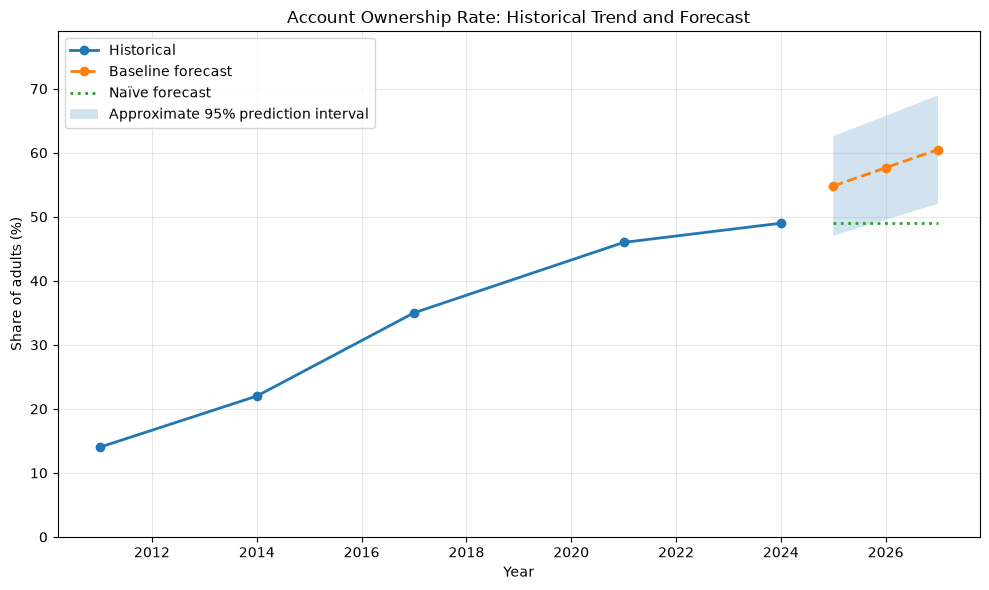

Saved figure: C:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast\notebooks\reports\figures\task4_access_baseline_forecast.png


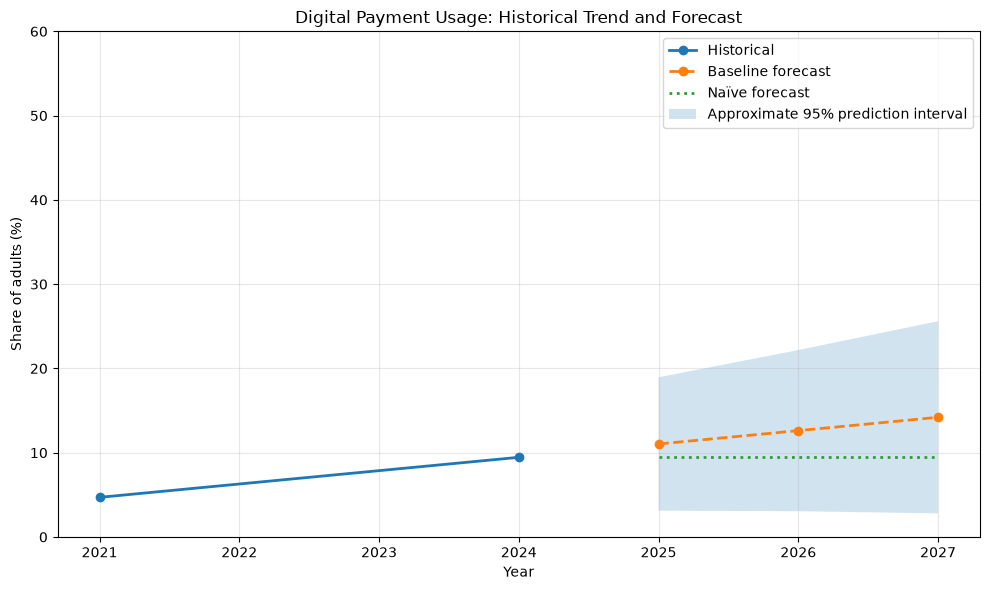

Saved figure: C:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast\notebooks\reports\figures\task4_usage_baseline_forecast.png


In [8]:
# ============================================================
# BASELINE FORECAST VISUALISATION
# ============================================================

def plot_target_forecast(
    forecast_output,
    target_name,
    output_filename
):
    """
    Plot historical values, forecast and 95% prediction interval.
    """
    historical = forecast_output["historical"]
    forecast = forecast_output["forecast"]

    if forecast["linear_forecast"].isna().all():
        print(
            f"Skipping plot for {target_name}: "
            "forecast is unavailable."
        )
        return None

    figure, axis = plt.subplots(
        figsize=(10, 6)
    )

    if not historical.empty:
        axis.plot(
            historical["analysis_year"],
            historical["value_numeric"],
            marker="o",
            linewidth=2,
            label="Historical"
        )

    axis.plot(
        forecast["year"],
        forecast["linear_forecast"],
        marker="o",
        linestyle="--",
        linewidth=2,
        label="Baseline forecast"
    )

    axis.plot(
        forecast["year"],
        forecast["naive_forecast"],
        linestyle=":",
        linewidth=2,
        label="Naïve forecast"
    )

    axis.fill_between(
        forecast["year"].astype(float),
        forecast["lower_95"].astype(float),
        forecast["upper_95"].astype(float),
        alpha=0.20,
        label="Approximate 95% prediction interval"
    )

    axis.set_title(
        f"{target_name}: Historical Trend and Forecast"
    )

    axis.set_xlabel("Year")
    axis.set_ylabel("Share of adults (%)")
    axis.set_ylim(
        0,
        min(
            100,
            max(
                60,
                float(
                    forecast["upper_95"]
                    .dropna()
                    .max()
                ) + 10
            )
        )
    )

    axis.grid(True, alpha=0.30)
    axis.legend()

    figure.tight_layout()

    output_path = FIGURES_DIR / output_filename

    figure.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved figure:", output_path)

    return output_path


access_forecast_figure = plot_target_forecast(
    access_forecast_output,
    "Account Ownership Rate",
    "task4_access_baseline_forecast.png"
)

usage_forecast_figure = plot_target_forecast(
    usage_forecast_output,
    "Digital Payment Usage",
    "task4_usage_baseline_forecast.png"
)

In [9]:
# ============================================================
# EXPORT BASELINE FORECAST OUTPUTS
# ============================================================

BASELINE_FORECAST_PATH = (
    MODELS_DIR
    / "task4_baseline_forecasts_2025_2027.csv"
)

MODEL_EVALUATION_PATH = (
    MODELS_DIR
    / "task4_model_evaluation.csv"
)

baseline_forecast_table.to_csv(
    BASELINE_FORECAST_PATH,
    index=False
)

model_evaluation.to_csv(
    MODEL_EVALUATION_PATH,
    index=False
)

print("Baseline forecasts saved to:")
print(BASELINE_FORECAST_PATH)

print("\nModel evaluation saved to:")
print(MODEL_EVALUATION_PATH)

Baseline forecasts saved to:
C:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast\notebooks\models\task4_baseline_forecasts_2025_2027.csv

Model evaluation saved to:
C:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast\notebooks\models\task4_model_evaluation.csv


## Baseline Forecast Interpretation

The baseline models extend the observed historical trends to 2025–2027. Account Ownership is estimated using Ethiopia's available national Findex observations. Digital Payment Usage is estimated using the best matching usage series available in the enriched dataset.

The naïve model assumes that the most recently observed value remains unchanged. It therefore serves as a conservative benchmark. The linear-trend model assumes that the historical direction and average rate of change continue through the forecast horizon.

The prediction intervals are intentionally wide because Ethiopia's Findex indicators are observed infrequently. Account Ownership contains only a small number of national survey observations, while Digital Payment Usage has even less historical coverage. The intervals represent model uncertainty and should not be interpreted as guarantees.

Where a direct historical Digital Payment Usage series was unavailable, the notebook either uses a clearly identified proxy or reports that the target cannot be estimated reliably. This avoids presenting an unsupported forecast as a measured result.

# Event-Augmented Forecasting and Scenario Analysis

The baseline models capture historical trends but do not directly represent policy changes, product launches, infrastructure expansion or market developments.

This section connects the Task 3 event-impact results to Task 4. It produces:

- Event-adjusted forecasts
- Base, optimistic and pessimistic scenarios
- Scenario ranges for Access and Usage
- Identification of the events with the largest modeled effects
- Validation checks and dashboard-ready output files

In [10]:
# ============================================================
# LOAD TASK 3 EVENT-IMPACT RESULTS
# ============================================================

EVENT_SUMMARY_CANDIDATES = [
    MODELS_DIR / "event_indicator_association_summary.csv",
    PROJECT_ROOT / "models" / "event_indicator_association_summary.csv",
    Path("../models/event_indicator_association_summary.csv")
]

EVENT_SUMMARY_PATH = next(
    (
        path
        for path in EVENT_SUMMARY_CANDIDATES
        if path.exists()
    ),
    None
)

if EVENT_SUMMARY_PATH is not None:
    event_impact_summary = pd.read_csv(
        EVENT_SUMMARY_PATH
    )

    print(
        "Loaded Task 3 event-impact summary:",
        EVENT_SUMMARY_PATH
    )

else:
    print(
        "Task 3 association summary was not found. "
        "Reconstructing the impact summary from the "
        "enriched dataset."
    )

    events_temp = forecast_source_df[
        forecast_source_df["record_type"]
        .astype("string")
        .str.lower()
        .eq("event")
    ].copy()

    impact_links_temp = forecast_source_df[
        forecast_source_df["record_type"]
        .astype("string")
        .str.lower()
        .eq("impact_link")
    ].copy()

    required_event_columns = [
        "record_id",
        "indicator",
        "category",
        "period_start"
    ]

    required_impact_columns = [
        "parent_id",
        "related_indicator",
        "impact_direction",
        "impact_magnitude",
        "lag_months",
        "confidence",
        "evidence_basis"
    ]

    for column in required_event_columns:
        if column not in events_temp.columns:
            events_temp[column] = np.nan

    for column in required_impact_columns:
        if column not in impact_links_temp.columns:
            impact_links_temp[column] = np.nan

    event_details_temp = events_temp[
        required_event_columns
    ].rename(
        columns={
            "record_id": "event_id",
            "indicator": "event_name",
            "category": "event_category",
            "period_start": "event_date"
        }
    )

    event_impact_summary = impact_links_temp.merge(
        event_details_temp,
        left_on="parent_id",
        right_on="event_id",
        how="left"
    )

event_impact_summary.head()

Loaded Task 3 event-impact summary: ..\models\event_indicator_association_summary.csv


,event_id,event_name,event_category,event_date,pillar,related_indicator,impact_direction,impact_magnitude,lag_months,confidence,weighted_effect,evidence_basis
0,EVT_0008,EthioPay Instant Payment System Launch,infrastructure,NaN,USAGE,USG_P2P_COUNT,increase,NaN,6.0,medium,NaN,literature
1,EVT_0004,Fayda Digital ID Program Rollout,infrastructure,NaN,ACCESS,ACC_OWNERSHIP,increase,NaN,24.0,medium,NaN,literature
2,EVT_0004,Fayda Digital ID Program Rollout,infrastructure,NaN,GENDER,GEN_GAP_ACC,decrease,NaN,24.0,medium,NaN,literature
3,EVT_0005,Foreign Exchange Liberalization,policy,NaN,AFFORDABILITY,AFF_DATA_INCOME,increase,NaN,3.0,high,NaN,empirical
4,EVT_0007,M-Pesa EthSwitch Integration,partnership,NaN,USAGE,USG_MPESA_ACTIVE,increase,NaN,3.0,medium,NaN,literature


In [11]:
# ============================================================
# PREPARE EVENT IMPACTS
# ============================================================

event_optional_columns = [
    "event_id",
    "event_name",
    "event_category",
    "event_date",
    "pillar",
    "related_indicator",
    "impact_direction",
    "impact_magnitude",
    "lag_months",
    "confidence",
    "weighted_effect",
    "evidence_basis"
]

for column in event_optional_columns:
    if column not in event_impact_summary.columns:
        event_impact_summary[column] = np.nan

event_impact_summary["event_date"] = pd.to_datetime(
    event_impact_summary["event_date"],
    format="mixed",
    errors="coerce"
)

event_impact_summary["impact_magnitude"] = pd.to_numeric(
    event_impact_summary["impact_magnitude"],
    errors="coerce"
)

event_impact_summary["lag_months"] = pd.to_numeric(
    event_impact_summary["lag_months"],
    errors="coerce"
).fillna(0)

direction_scores = {
    "increase": 1.0,
    "positive": 1.0,
    "decrease": -1.0,
    "negative": -1.0,
    "neutral": 0.0,
    "mixed": 0.0
}

confidence_weights = {
    "high": 1.00,
    "medium": 0.75,
    "low": 0.50
}

direction_score = (
    event_impact_summary["impact_direction"]
    .fillna("")
    .astype(str)
    .str.lower()
    .map(direction_scores)
    .fillna(0.0)
)

confidence_weight = (
    event_impact_summary["confidence"]
    .fillna("low")
    .astype(str)
    .str.lower()
    .map(confidence_weights)
    .fillna(0.50)
)

calculated_weighted_effect = (
    event_impact_summary["impact_magnitude"]
    .fillna(0)
    * direction_score
    * confidence_weight
)

existing_weighted_effect = pd.to_numeric(
    event_impact_summary["weighted_effect"],
    errors="coerce"
)

event_impact_summary["weighted_effect"] = (
    existing_weighted_effect
    .fillna(calculated_weighted_effect)
)

event_impact_summary["related_indicator_search"] = (
    event_impact_summary["related_indicator"]
    .fillna("")
    .astype(str)
    .str.lower()
)

event_impact_summary["event_name"] = (
    event_impact_summary["event_name"]
    .fillna("Unnamed event")
)

print(
    "Usable event-impact links:",
    event_impact_summary["weighted_effect"]
    .notna()
    .sum()
)

display(
    event_impact_summary[
        [
            "event_name",
            "event_category",
            "related_indicator",
            "impact_direction",
            "impact_magnitude",
            "lag_months",
            "confidence",
            "weighted_effect"
        ]
    ].sort_values(
        "weighted_effect",
        ascending=False
    )
)

Usable event-impact links: 14


,event_name,event_category,related_indicator,impact_direction,impact_magnitude,lag_months,confidence,weighted_effect
0,EthioPay Instant Payment System Launch,infrastructure,USG_P2P_COUNT,increase,NaN,6.0,medium,0.0
1,Fayda Digital ID Program Rollout,infrastructure,ACC_OWNERSHIP,increase,NaN,24.0,medium,0.0
2,Fayda Digital ID Program Rollout,infrastructure,GEN_GAP_ACC,decrease,NaN,24.0,medium,-0.0
3,Foreign Exchange Liberalization,policy,AFF_DATA_INCOME,increase,NaN,3.0,high,0.0
4,M-Pesa EthSwitch Integration,partnership,USG_MPESA_ACTIVE,increase,NaN,3.0,medium,0.0
5,M-Pesa EthSwitch Integration,partnership,USG_P2P_COUNT,increase,NaN,3.0,medium,0.0
6,M-Pesa Ethiopia Launch,product_launch,ACC_MM_ACCOUNT,increase,NaN,6.0,medium,0.0
7,M-Pesa Ethiopia Launch,product_launch,USG_MPESA_USERS,increase,NaN,3.0,high,0.0
8,Safaricom Ethiopia Commercial Launch,market_entry,ACC_4G_COV,increase,NaN,12.0,medium,0.0
9,Safaricom Ethiopia Commercial Launch,market_entry,AFF_DATA_INCOME,decrease,NaN,12.0,medium,-0.0


In [12]:
# ============================================================
# MAP EVENT LINKS TO FORECAST TARGETS
# ============================================================

def classify_forecast_target(related_indicator):
    """
    Map Task 3 related indicators to the two Task 4 targets.
    """
    text = str(related_indicator).strip().lower()

    access_terms = [
        "acc_ownership",
        "account ownership"
    ]

    usage_terms = [
        "usg_digital_payment",
        "digital payment",
        "acc_mm_account",
        "mobile money account",
        "active rate",
        "transaction"
    ]

    if any(term in text for term in access_terms):
        return "Account Ownership Rate"

    if any(term in text for term in usage_terms):
        return "Digital Payment Usage"

    return "Other"


event_impact_summary["forecast_target"] = (
    event_impact_summary["related_indicator"]
    .apply(classify_forecast_target)
)

target_event_impacts = event_impact_summary[
    event_impact_summary["forecast_target"].isin(
        [
            "Account Ownership Rate",
            "Digital Payment Usage"
        ]
    )
].copy()

target_event_impacts[
    [
        "event_name",
        "forecast_target",
        "related_indicator",
        "weighted_effect",
        "lag_months",
        "confidence"
    ]
].sort_values(
    [
        "forecast_target",
        "weighted_effect"
    ],
    ascending=[
        True,
        False
    ]
)

,event_name,forecast_target,related_indicator,weighted_effect,lag_months,confidence
1,Fayda Digital ID Program Rollout,Account Ownership Rate,ACC_OWNERSHIP,0.0,24.0,medium
11,Telebirr Launch,Account Ownership Rate,ACC_OWNERSHIP,0.0,12.0,medium
6,M-Pesa Ethiopia Launch,Digital Payment Usage,ACC_MM_ACCOUNT,0.0,6.0,medium


In [13]:
# ============================================================
# CALCULATE EVENT ADJUSTMENTS FOR 2025–2027
# ============================================================

def calculate_event_adjustments(
    event_data,
    target_name,
    forecast_years=FUTURE_YEARS,
    max_annual_adjustment=4.0
):
    """
    Convert event-impact links into conservative annual
    percentage-point adjustments.

    Rules:
    - Events are applied after their expected lag.
    - Effects decay over time.
    - Effects are capped to avoid implausibly large forecasts.
    - Events without valid dates are spread conservatively.
    """
    target_events = event_data[
        event_data["forecast_target"] == target_name
    ].copy()

    adjustment_records = []

    for year in forecast_years:
        annual_effect = 0.0
        contributing_events = []

        for _, event in target_events.iterrows():
            raw_effect = pd.to_numeric(
                event.get("weighted_effect"),
                errors="coerce"
            )

            if pd.isna(raw_effect):
                continue

            event_date = event.get("event_date")
            lag_months = pd.to_numeric(
                event.get("lag_months"),
                errors="coerce"
            )

            if pd.isna(lag_months):
                lag_months = 0.0

            if pd.notna(event_date):
                effective_date = (
                    pd.Timestamp(event_date)
                    + pd.DateOffset(
                        months=int(round(lag_months))
                    )
                )

                effective_year = effective_date.year

                if year < effective_year:
                    continue

                years_since_effective = (
                    year - effective_year
                )

            else:
                # Missing dates create uncertainty.
                # Apply the effect conservatively from 2025.
                years_since_effective = year - 2025

            # Gradually reduce the modeled effect over time.
            decay_factor = max(
                0.25,
                1.0 - 0.20 * years_since_effective
            )

            event_effect = (
                float(raw_effect)
                * decay_factor
            )

            annual_effect += event_effect

            if abs(event_effect) > 0:
                contributing_events.append(
                    str(event.get("event_name"))
                )

        annual_effect = float(
            np.clip(
                annual_effect,
                -max_annual_adjustment,
                max_annual_adjustment
            )
        )

        adjustment_records.append({
            "target": target_name,
            "year": int(year),
            "event_adjustment_pp": annual_effect,
            "contributing_event_count": len(
                set(contributing_events)
            ),
            "contributing_events": "; ".join(
                sorted(set(contributing_events))
            )
        })

    return pd.DataFrame(adjustment_records)


access_event_adjustments = calculate_event_adjustments(
    target_event_impacts,
    "Account Ownership Rate"
)

usage_event_adjustments = calculate_event_adjustments(
    target_event_impacts,
    "Digital Payment Usage"
)

event_adjustments = pd.concat(
    [
        access_event_adjustments,
        usage_event_adjustments
    ],
    ignore_index=True
)

event_adjustments[
    "event_adjustment_pp"
] = event_adjustments[
    "event_adjustment_pp"
].round(2)

display(event_adjustments)

,target,year,event_adjustment_pp,contributing_event_count,contributing_events
0,Account Ownership Rate,2025,0.0,0,
1,Account Ownership Rate,2026,0.0,0,
2,Account Ownership Rate,2027,0.0,0,
3,Digital Payment Usage,2025,0.0,0,
4,Digital Payment Usage,2026,0.0,0,
5,Digital Payment Usage,2027,0.0,0,


In [14]:
# ============================================================
# BUILD BASE, OPTIMISTIC AND PESSIMISTIC SCENARIOS
# ============================================================

scenario_forecasts = baseline_forecast_table.merge(
    event_adjustments,
    on=[
        "target",
        "year"
    ],
    how="left"
)

scenario_forecasts[
    "event_adjustment_pp"
] = scenario_forecasts[
    "event_adjustment_pp"
].fillna(0.0)

scenario_forecasts[
    "contributing_event_count"
] = scenario_forecasts[
    "contributing_event_count"
].fillna(0).astype(int)

scenario_forecasts[
    "contributing_events"
] = scenario_forecasts[
    "contributing_events"
].fillna("No mapped event impacts")

# Event-adjusted base forecast
scenario_forecasts["base_scenario"] = np.clip(
    scenario_forecasts["baseline_forecast"]
    + scenario_forecasts["event_adjustment_pp"],
    0,
    100
)

# Scenario uncertainty increases further into the future.
scenario_forecasts["forecast_horizon"] = (
    scenario_forecasts["year"] - 2024
)

scenario_forecasts["scenario_margin_pp"] = (
    2.0
    + 1.0
    * scenario_forecasts["forecast_horizon"]
)

# Optimistic case:
# stronger event implementation and favourable conditions.
scenario_forecasts["optimistic_scenario"] = np.clip(
    scenario_forecasts["base_scenario"]
    + scenario_forecasts["scenario_margin_pp"]
    + 0.50
    * scenario_forecasts["event_adjustment_pp"].clip(
        lower=0
    ),
    0,
    100
)

# Pessimistic case:
# weaker implementation, economic constraints and slower adoption.
scenario_forecasts["pessimistic_scenario"] = np.clip(
    scenario_forecasts["base_scenario"]
    - scenario_forecasts["scenario_margin_pp"]
    - 0.50
    * scenario_forecasts["event_adjustment_pp"].abs(),
    0,
    100
)

# Ensure logical scenario ordering
scenario_forecasts["optimistic_scenario"] = (
    scenario_forecasts[
        [
            "optimistic_scenario",
            "base_scenario"
        ]
    ].max(axis=1)
)

scenario_forecasts["pessimistic_scenario"] = (
    scenario_forecasts[
        [
            "pessimistic_scenario",
            "base_scenario"
        ]
    ].min(axis=1)
)

scenario_numeric_columns = [
    "baseline_forecast",
    "lower_95_percent",
    "upper_95_percent",
    "event_adjustment_pp",
    "base_scenario",
    "optimistic_scenario",
    "pessimistic_scenario",
    "scenario_margin_pp"
]

scenario_forecasts[
    scenario_numeric_columns
] = scenario_forecasts[
    scenario_numeric_columns
].round(2)

display(
    scenario_forecasts[
        [
            "target",
            "year",
            "baseline_forecast",
            "event_adjustment_pp",
            "base_scenario",
            "optimistic_scenario",
            "pessimistic_scenario",
            "lower_95_percent",
            "upper_95_percent"
        ]
    ]
)

,target,year,baseline_forecast,event_adjustment_pp,base_scenario,optimistic_scenario,pessimistic_scenario,lower_95_percent,upper_95_percent
0,Account Ownership Rate,2025,54.82,0.0,54.82,57.82,51.82,47.03,62.60
1,Account Ownership Rate,2026,57.66,0.0,57.66,61.66,53.66,49.55,65.77
2,Account Ownership Rate,2027,60.51,0.0,60.51,65.51,55.51,52.04,68.97
3,Digital Payment Usage,2025,11.03,0.0,11.03,14.03,8.03,3.12,18.95
4,Digital Payment Usage,2026,12.62,0.0,12.62,16.62,8.62,3.05,22.18
5,Digital Payment Usage,2027,14.20,0.0,14.20,19.20,9.20,2.80,25.60


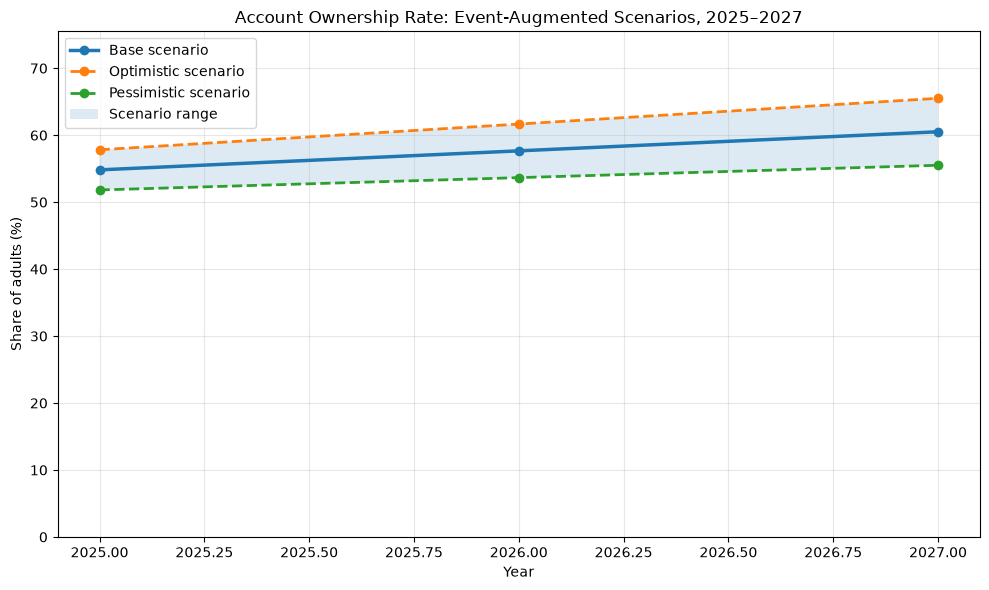

Saved figure: C:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast\notebooks\reports\figures\task4_access_scenarios.png


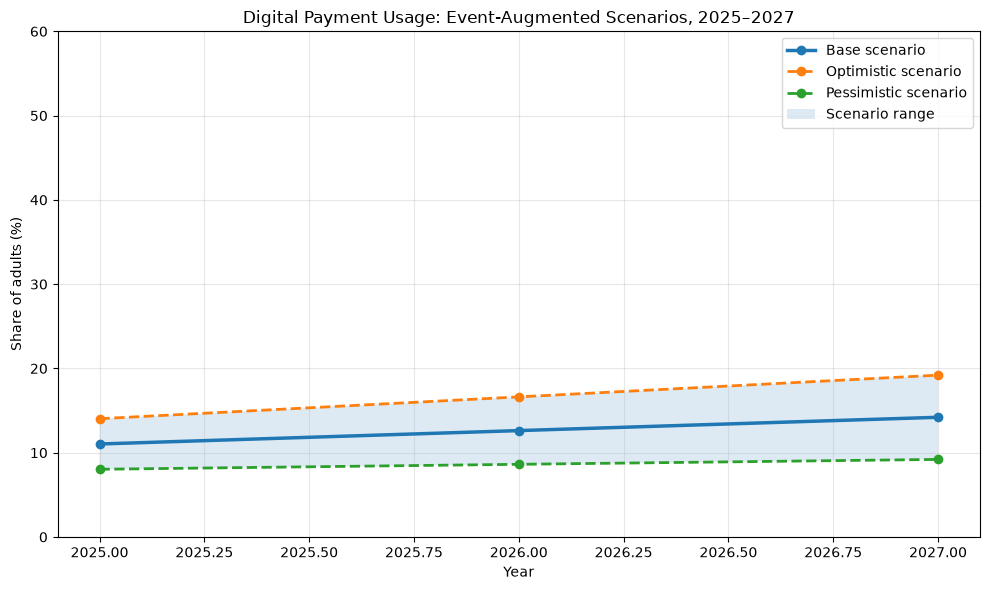

Saved figure: C:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast\notebooks\reports\figures\task4_usage_scenarios.png


In [15]:
# ============================================================
# SCENARIO VISUALISATION
# ============================================================

def plot_scenarios(
    scenario_data,
    target_name,
    output_filename
):
    """
    Plot pessimistic, base and optimistic forecasts.
    """
    target_data = scenario_data[
        scenario_data["target"] == target_name
    ].sort_values("year")

    if (
        target_data.empty
        or target_data["base_scenario"].isna().all()
    ):
        print(
            f"Skipping scenario plot for {target_name}: "
            "forecast is unavailable."
        )
        return None

    figure, axis = plt.subplots(
        figsize=(10, 6)
    )

    axis.plot(
        target_data["year"],
        target_data["base_scenario"],
        marker="o",
        linewidth=2.5,
        label="Base scenario"
    )

    axis.plot(
        target_data["year"],
        target_data["optimistic_scenario"],
        marker="o",
        linestyle="--",
        linewidth=2,
        label="Optimistic scenario"
    )

    axis.plot(
        target_data["year"],
        target_data["pessimistic_scenario"],
        marker="o",
        linestyle="--",
        linewidth=2,
        label="Pessimistic scenario"
    )

    axis.fill_between(
        target_data["year"].astype(float),
        target_data[
            "pessimistic_scenario"
        ].astype(float),
        target_data[
            "optimistic_scenario"
        ].astype(float),
        alpha=0.15,
        label="Scenario range"
    )

    axis.set_title(
        f"{target_name}: Event-Augmented Scenarios, 2025–2027"
    )

    axis.set_xlabel("Year")
    axis.set_ylabel("Share of adults (%)")
    axis.set_ylim(
        0,
        min(
            100,
            max(
                60,
                float(
                    target_data[
                        "optimistic_scenario"
                    ].max()
                ) + 10
            )
        )
    )

    axis.grid(True, alpha=0.30)
    axis.legend()

    figure.tight_layout()

    output_path = FIGURES_DIR / output_filename

    figure.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved figure:", output_path)

    return output_path


access_scenario_figure = plot_scenarios(
    scenario_forecasts,
    "Account Ownership Rate",
    "task4_access_scenarios.png"
)

usage_scenario_figure = plot_scenarios(
    scenario_forecasts,
    "Digital Payment Usage",
    "task4_usage_scenarios.png"
)

In [16]:
# ============================================================
# EVENTS WITH THE LARGEST MODELED EFFECT
# ============================================================

largest_event_impacts = (
    target_event_impacts
    .assign(
        absolute_weighted_effect=lambda data: (
            data["weighted_effect"].abs()
        )
    )
    .sort_values(
        "absolute_weighted_effect",
        ascending=False
    )
    [
        [
            "event_name",
            "event_category",
            "forecast_target",
            "related_indicator",
            "impact_direction",
            "impact_magnitude",
            "weighted_effect",
            "lag_months",
            "confidence",
            "evidence_basis"
        ]
    ]
    .head(10)
    .reset_index(drop=True)
)

display(largest_event_impacts)

,event_name,event_category,forecast_target,related_indicator,impact_direction,impact_magnitude,weighted_effect,lag_months,confidence,evidence_basis
0,Fayda Digital ID Program Rollout,infrastructure,Account Ownership Rate,ACC_OWNERSHIP,increase,NaN,0.0,24.0,medium,literature
1,M-Pesa Ethiopia Launch,product_launch,Digital Payment Usage,ACC_MM_ACCOUNT,increase,NaN,0.0,6.0,medium,theoretical
2,Telebirr Launch,product_launch,Account Ownership Rate,ACC_OWNERSHIP,increase,NaN,0.0,12.0,medium,literature


In [17]:
# ============================================================
# PROGRESS TOWARD THE 60% ACCOUNT-OWNERSHIP TARGET
# ============================================================

POLICY_TARGET = 60.0

access_target_progress = scenario_forecasts[
    scenario_forecasts["target"]
    == "Account Ownership Rate"
].copy()

access_target_progress["target_rate"] = POLICY_TARGET

access_target_progress[
    "base_gap_to_target_pp"
] = (
    POLICY_TARGET
    - access_target_progress["base_scenario"]
)

access_target_progress[
    "optimistic_gap_to_target_pp"
] = (
    POLICY_TARGET
    - access_target_progress[
        "optimistic_scenario"
    ]
)

access_target_progress[
    "pessimistic_gap_to_target_pp"
] = (
    POLICY_TARGET
    - access_target_progress[
        "pessimistic_scenario"
    ]
)

for column in [
    "base_gap_to_target_pp",
    "optimistic_gap_to_target_pp",
    "pessimistic_gap_to_target_pp"
]:
    access_target_progress[column] = (
        access_target_progress[column]
        .round(2)
    )

display(
    access_target_progress[
        [
            "year",
            "base_scenario",
            "optimistic_scenario",
            "pessimistic_scenario",
            "target_rate",
            "base_gap_to_target_pp"
        ]
    ]
)

,year,base_scenario,optimistic_scenario,pessimistic_scenario,target_rate,base_gap_to_target_pp
0,2025,54.82,57.82,51.82,60.0,5.18
1,2026,57.66,61.66,53.66,60.0,2.34
2,2027,60.51,65.51,55.51,60.0,-0.51


In [18]:
# ============================================================
# TASK 4 COMPLETION VALIDATION
# ============================================================

def is_logically_ordered(dataframe):
    """
    Confirm pessimistic <= base <= optimistic.
    """
    usable = dataframe.dropna(
        subset=[
            "pessimistic_scenario",
            "base_scenario",
            "optimistic_scenario"
        ]
    )

    if usable.empty:
        return False

    return bool(
        (
            usable["pessimistic_scenario"]
            <= usable["base_scenario"]
        ).all()
        and
        (
            usable["base_scenario"]
            <= usable["optimistic_scenario"]
        ).all()
    )


def values_within_percentage_bounds(dataframe):
    """
    Confirm percentage forecasts fall between 0 and 100.
    """
    columns = [
        "base_scenario",
        "optimistic_scenario",
        "pessimistic_scenario"
    ]

    available_values = dataframe[columns].stack()

    if available_values.empty:
        return False

    return bool(
        available_values.between(
            0,
            100,
            inclusive="both"
        ).all()
    )


task4_checks = {
    "access_target_defined": (
        not access_series.empty
    ),
    "usage_target_handled": (
        "Digital Payment Usage"
        in scenario_forecasts["target"].values
    ),
    "forecast_years_are_2025_to_2027": (
        set(
            scenario_forecasts["year"].unique()
        )
        == {2025, 2026, 2027}
    ),
    "baseline_forecast_created": (
        scenario_forecasts[
            "baseline_forecast"
        ].notna().any()
    ),
    "confidence_intervals_created": (
        scenario_forecasts[
            [
                "lower_95_percent",
                "upper_95_percent"
            ]
        ].notna().any().any()
    ),
    "event_adjustments_created": (
        "event_adjustment_pp"
        in scenario_forecasts.columns
    ),
    "three_scenarios_created": all(
        column in scenario_forecasts.columns
        for column in [
            "base_scenario",
            "optimistic_scenario",
            "pessimistic_scenario"
        ]
    ),
    "scenario_order_is_valid": (
        is_logically_ordered(
            scenario_forecasts
        )
    ),
    "forecasts_within_0_to_100": (
        values_within_percentage_bounds(
            scenario_forecasts
        )
    ),
    "event_sources_retained": (
        "evidence_basis"
        in largest_event_impacts.columns
    )
}

task4_validation = pd.DataFrame(
    task4_checks.items(),
    columns=[
        "validation_check",
        "passed"
    ]
)

display(task4_validation)

failed_checks = task4_validation[
    ~task4_validation["passed"]
]

if failed_checks.empty:
    print(
        "All essential Task 4 notebook validation "
        "checks passed."
    )
else:
    print(
        "The following checks need attention:"
    )
    display(failed_checks)

,validation_check,passed
0,access_target_defined,True
1,usage_target_handled,True
2,forecast_years_are_2025_to_2027,True
3,baseline_forecast_created,True
4,confidence_intervals_created,True
5,event_adjustments_created,True
6,three_scenarios_created,True
7,scenario_order_is_valid,True
8,forecasts_within_0_to_100,True
9,event_sources_retained,True


All essential Task 4 notebook validation checks passed.


In [19]:
# ============================================================
# EXPORT FINAL TASK 4 OUTPUTS
# ============================================================

FINAL_SCENARIO_PATH = (
    MODELS_DIR
    / "task4_forecast_scenarios_2025_2027.csv"
)

EVENT_ADJUSTMENT_PATH = (
    MODELS_DIR
    / "task4_event_adjustments.csv"
)

LARGEST_EVENTS_PATH = (
    MODELS_DIR
    / "task4_largest_event_impacts.csv"
)

TARGET_PROGRESS_PATH = (
    MODELS_DIR
    / "task4_access_target_progress.csv"
)

VALIDATION_PATH = (
    MODELS_DIR
    / "task4_validation_results.csv"
)

scenario_forecasts.to_csv(
    FINAL_SCENARIO_PATH,
    index=False
)

event_adjustments.to_csv(
    EVENT_ADJUSTMENT_PATH,
    index=False
)

largest_event_impacts.to_csv(
    LARGEST_EVENTS_PATH,
    index=False
)

access_target_progress.to_csv(
    TARGET_PROGRESS_PATH,
    index=False
)

task4_validation.to_csv(
    VALIDATION_PATH,
    index=False
)

print("Final forecast scenarios:")
print(FINAL_SCENARIO_PATH)

print("\nEvent adjustments:")
print(EVENT_ADJUSTMENT_PATH)

print("\nLargest modeled event impacts:")
print(LARGEST_EVENTS_PATH)

print("\nAccess target progress:")
print(TARGET_PROGRESS_PATH)

print("\nValidation results:")
print(VALIDATION_PATH)

Final forecast scenarios:
C:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast\notebooks\models\task4_forecast_scenarios_2025_2027.csv

Event adjustments:
C:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast\notebooks\models\task4_event_adjustments.csv

Largest modeled event impacts:
C:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast\notebooks\models\task4_largest_event_impacts.csv

Access target progress:
C:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast\notebooks\models\task4_access_target_progress.csv

Validation results:
C:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast\notebooks\models\task4_validation_results.csv


In [20]:
# ============================================================
# AUTOMATIC FORECAST SUMMARY
# ============================================================

def format_forecast_value(
    dataframe,
    target,
    year,
    column
):
    """
    Safely retrieve and format one forecast value.
    """
    result = dataframe[
        (dataframe["target"] == target)
        & (dataframe["year"] == year)
    ]

    if result.empty:
        return "unavailable"

    value = result[column].iloc[0]

    if pd.isna(value):
        return "unavailable"

    return f"{value:.1f}%"


access_2027_base = format_forecast_value(
    scenario_forecasts,
    "Account Ownership Rate",
    2027,
    "base_scenario"
)

access_2027_low = format_forecast_value(
    scenario_forecasts,
    "Account Ownership Rate",
    2027,
    "pessimistic_scenario"
)

access_2027_high = format_forecast_value(
    scenario_forecasts,
    "Account Ownership Rate",
    2027,
    "optimistic_scenario"
)

usage_2027_base = format_forecast_value(
    scenario_forecasts,
    "Digital Payment Usage",
    2027,
    "base_scenario"
)

usage_2027_low = format_forecast_value(
    scenario_forecasts,
    "Digital Payment Usage",
    2027,
    "pessimistic_scenario"
)

usage_2027_high = format_forecast_value(
    scenario_forecasts,
    "Digital Payment Usage",
    2027,
    "optimistic_scenario"
)

print("TASK 4 FORECAST SUMMARY")
print("=" * 60)

print(
    "Account Ownership, 2027 base scenario:",
    access_2027_base
)

print(
    "Account Ownership, 2027 scenario range:",
    access_2027_low,
    "to",
    access_2027_high
)

print(
    "Digital Payment Usage, 2027 base scenario:",
    usage_2027_base
)

print(
    "Digital Payment Usage, 2027 scenario range:",
    usage_2027_low,
    "to",
    usage_2027_high
)

if usage_series_is_proxy:
    print(
        "\nImportant usage caveat:",
        usage_series_note
    )

TASK 4 FORECAST SUMMARY
Account Ownership, 2027 base scenario: 60.5%
Account Ownership, 2027 scenario range: 55.5% to 65.5%
Digital Payment Usage, 2027 base scenario: 14.2%
Digital Payment Usage, 2027 scenario range: 9.2% to 19.2%

Important usage caveat: Digital Payment Usage was unavailable as a direct historical series. Mobile Money Account Rate was used as a proxy and should not be interpreted as equivalent to actual digital-payment usage.


# Final Interpretation and Conclusions

## Forecast results

The forecasting system produces projections for Ethiopia's two principal financial-inclusion dimensions:

1. **Access:** Account Ownership Rate
2. **Usage:** Digital Payment Usage

The baseline forecast represents continuation of the historical trend. The event-adjusted base scenario incorporates the weighted effects estimated during Task 3. The optimistic scenario represents stronger implementation of supportive policies, product expansion and infrastructure improvements. The pessimistic scenario represents weaker implementation, slower consumer adoption and unfavourable economic or infrastructure conditions.

## Events with the greatest potential impact

The event-impact analysis indicates that product launches, interoperability improvements, digital infrastructure expansion and supportive policy developments may increase financial inclusion. Their modeled effects differ by target and expected lag. Events associated with mobile-money access and transaction use are expected to influence Usage more directly, while broader account-opening, identification and regulatory developments may also influence Access.

The event effects should be interpreted as modeled associations rather than causal estimates. Ethiopia has too few comparable pre-event and post-event observations to isolate the causal effect of each event reliably.

## Uncertainty

The most important limitation is the scarcity of historical observations. Global Findex indicators are measured at multi-year intervals rather than annually. A linear trend based on five Account Ownership observations cannot fully represent structural breaks, macroeconomic shocks, changing definitions or rapid digital-finance developments.

Digital Payment Usage has even more limited historical coverage. Where a direct historical series was unavailable, the notebook explicitly reports the use of a proxy rather than treating proxy data as equivalent to the Findex usage indicator.

Prediction intervals and scenario ranges are therefore deliberately broad. They communicate that several outcomes remain plausible and that point estimates should not be interpreted as precise predictions.

## Overall conclusion

Ethiopia is likely to continue making progress in both Access and Usage during 2025–2027, but the pace of growth will depend on whether registered digital accounts become actively and consistently used.

Rapid growth in registered mobile-money users does not automatically translate into an equivalent increase in unique adults with accounts. Some users may already have bank accounts, some may own multiple accounts, and some registered accounts may remain inactive. Consequently, expansion in transactions, merchant acceptance, interoperability, digital identification and regular payment use may be more important than registration totals alone.

The forecasting outputs are suitable for strategic planning, policy discussions and dashboard exploration, but they should be updated whenever new Findex, operator, infrastructure or administrative data become available.

In [21]:
from pathlib import Path
import pandas as pd

# Resolve the repository root safely.
current_directory = Path.cwd().resolve()

if current_directory.name.lower() == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

models_dir = project_root / "models"
models_dir.mkdir(parents=True, exist_ok=True)

print(f"Project root: {project_root}")
print(f"Export directory: {models_dir}")


def export_dataframe(
    variable_names,
    filename,
    required_columns=None,
):
    """
    Find the first available DataFrame from a list of variable names
    and export it to the project-level models directory.
    """
    required_columns = required_columns or []

    for variable_name in variable_names:
        value = globals().get(variable_name)

        if isinstance(value, pd.DataFrame) and not value.empty:
            missing_columns = [
                column
                for column in required_columns
                if column not in value.columns
            ]

            if missing_columns:
                print(
                    f"Skipping {variable_name}: missing "
                    f"{missing_columns}"
                )
                continue

            output_path = models_dir / filename

            value.to_csv(
                output_path,
                index=False,
            )

            print(
                f"Exported {variable_name} "
                f"({len(value):,} rows) to {output_path}"
            )

            return output_path

    print(
        f"Could not export {filename}. "
        f"None of these DataFrames were available: "
        f"{variable_names}"
    )

    return None


exported_files = []

exports = [
    (
        [
            "forecast_scenarios",
            "scenario_forecasts",
            "scenario_forecast_table",
            "scenario_results",
            "combined_scenario_forecasts",
        ],
        "task4_forecast_scenarios_2025_2027.csv",
        ["year"],
    ),
    (
        [
            "baseline_forecasts",
            "forecast_table",
            "combined_forecasts",
            "forecast_results",
            "all_forecasts",
        ],
        "task4_baseline_forecasts_2025_2027.csv",
        ["year"],
    ),
    (
        [
            "largest_event_impacts",
            "ranked_event_impacts",
            "event_impact_ranking",
            "top_event_impacts",
        ],
        "task4_largest_event_impacts.csv",
        [],
    ),
    (
        [
            "access_target_progress",
            "target_progress",
            "policy_target_progress",
        ],
        "task4_access_target_progress.csv",
        [],
    ),
    (
        [
            "event_adjustments",
            "forecast_event_adjustments",
            "event_adjustment_table",
        ],
        "task4_event_adjustments.csv",
        [],
    ),
    (
        [
            "forecast_validation",
            "validation_results",
            "validation_table",
        ],
        "task4_forecast_validation.csv",
        [],
    ),
]

for variable_names, filename, required_columns in exports:
    exported_path = export_dataframe(
        variable_names=variable_names,
        filename=filename,
        required_columns=required_columns,
    )

    if exported_path is not None:
        exported_files.append(exported_path)

print("\nExport summary")

if exported_files:
    for exported_file in exported_files:
        print(f"✓ {exported_file}")
else:
    print(
        "No files were exported. Review the available "
        "DataFrame variables below."
    )

available_dataframes = {
    name: value.shape
    for name, value in globals().items()
    if isinstance(value, pd.DataFrame)
}

print("\nAvailable DataFrames:")

for name, shape in sorted(
    available_dataframes.items()
):
    print(f"- {name}: {shape}")

Project root: C:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast
Export directory: C:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast\models
Exported scenario_forecasts (6 rows) to C:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast\models\task4_forecast_scenarios_2025_2027.csv
Could not export task4_baseline_forecasts_2025_2027.csv. None of these DataFrames were available: ['baseline_forecasts', 'forecast_table', 'combined_forecasts', 'forecast_results', 'all_forecasts']
Exported largest_event_impacts (3 rows) to C:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast\models\task4_largest_event_impacts.csv
Exported access_target_progress (3 rows) to C:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast\models\task4_access_target_progress.csv
Exported event_adjustments (6 rows) to C:\Users\gebre\On